# Austin Weather EDA

## 1️⃣ Project Overview

This project analyzes historical weather data from Austin, Texas, with a primary focus on temperature dynamics, seasonal behavior, and long-term climatic trends.

The objective is to transform raw daily weather observations into structured analytical insights through data cleaning, visualization, and statistical aggregation techniques.

The analysis includes:
- Data inspection and preprocessing
- Correlation analysis
- Time-series visualization
- Rolling and expanding trend smoothing
- Seasonality assessment
- Year-over-year trend validation using complete data only

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/matzim95/ML-datasets/master/austin_weather.csv"
df_austin = pd.read_csv(url)


## 2️⃣ Data Inspection

This initial inspection step provides an overview of the dataset structure, data types, and statistical summaries.  

The goal is to understand the variable distribution, detect potential inconsistencies, and identify missing values before applying any transformations.

In [3]:
df_austin.head()

,Date,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,...,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events
0,2013-12-21,74,60,45,67,49,43,93,75,57,...,29.68,29.59,10,7,2,20,4,31,0.46,"Rain , Thunderstorm"
1,2013-12-22,56,48,39,43,36,28,93,68,43,...,30.13,29.87,10,10,5,16,6,25,0,
2,2013-12-23,58,45,32,31,27,23,76,52,27,...,30.49,30.41,10,10,10,8,3,12,0,
3,2013-12-24,61,46,31,36,28,21,89,56,22,...,30.45,30.3,10,10,7,12,4,20,0,
4,2013-12-25,58,50,41,44,40,36,86,71,56,...,30.33,30.27,10,10,7,10,2,16,T,


In [4]:
df_austin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Date                        1319 non-null   str  
 1   TempHighF                   1319 non-null   int64
 2   TempAvgF                    1319 non-null   int64
 3   TempLowF                    1319 non-null   int64
 4   DewPointHighF               1319 non-null   str  
 5   DewPointAvgF                1319 non-null   str  
 6   DewPointLowF                1319 non-null   str  
 7   HumidityHighPercent         1319 non-null   str  
 8   HumidityAvgPercent          1319 non-null   str  
 9   HumidityLowPercent          1319 non-null   str  
 10  SeaLevelPressureHighInches  1319 non-null   str  
 11  SeaLevelPressureAvgInches   1319 non-null   str  
 12  SeaLevelPressureLowInches   1319 non-null   str  
 13  VisibilityHighMiles         1319 non-null   str  
 14  VisibilityAvgMiles 

In [5]:
df_austin.describe()

,TempHighF,TempAvgF,TempLowF
count,1319.000000,1319.000000,1319.000000
mean,80.862775,70.642911,59.902957
std,14.766523,14.045904,14.190648
min,32.000000,29.000000,19.000000
25%,72.000000,62.000000,49.000000
50%,83.000000,73.000000,63.000000
75%,92.000000,83.000000,73.000000
max,107.000000,93.000000,81.000000


## 3️⃣ Data Cleaning & Preprocessing

In this phase, date and numerical columns are converted into appropriate data types to ensure accurate analysis.  

Missing values in critical temperature and humidity variables are removed to ensure analytical reliability.  

Minor gaps in dew point observations (less than 1% of the dataset) are imputed using the column mean, as their impact on overall trend analysis is statistically negligible.

In [6]:
df_austin["Date"] = pd.to_datetime(df_austin["Date"], errors="coerce")

cols_num = ["TempHighF","TempAvgF","TempLowF","HumidityAvgPercent","DewPointAvgF"]
for col in cols_num:
    df_austin[col] = pd.to_numeric(df_austin[col], errors="coerce")

df_austin = df_austin.dropna(subset=["Date","TempAvgF","TempHighF","TempLowF","HumidityAvgPercent"])
df_austin = df_austin.sort_values("Date")
df_austin.head()

,Date,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,...,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events
0,2013-12-21,74,60,45,67,49.0,43,93,75.0,57,...,29.68,29.59,10,7,2,20,4,31,0.46,"Rain , Thunderstorm"
1,2013-12-22,56,48,39,43,36.0,28,93,68.0,43,...,30.13,29.87,10,10,5,16,6,25,0,
2,2013-12-23,58,45,32,31,27.0,23,76,52.0,27,...,30.49,30.41,10,10,10,8,3,12,0,
3,2013-12-24,61,46,31,36,28.0,21,89,56.0,22,...,30.45,30.3,10,10,7,12,4,20,0,
4,2013-12-25,58,50,41,44,40.0,36,86,71.0,56,...,30.33,30.27,10,10,7,10,2,16,T,


In [7]:
print(df_austin.isna().sum())

Date                          0
TempHighF                     0
TempAvgF                      0
TempLowF                      0
DewPointHighF                 0
DewPointAvgF                  5
DewPointLowF                  0
HumidityHighPercent           0
HumidityAvgPercent            0
HumidityLowPercent            0
SeaLevelPressureHighInches    0
SeaLevelPressureAvgInches     0
SeaLevelPressureLowInches     0
VisibilityHighMiles           0
VisibilityAvgMiles            0
VisibilityLowMiles            0
WindHighMPH                   0
WindAvgMPH                    0
WindGustMPH                   0
PrecipitationSumInches        0
Events                        0
dtype: int64


Only 5 missing values were detected in DewPointAvgF.
Since this represents less than 1% of the dataset, missing values were replaced with the column mean to preserve dataset integrity.

In [8]:
df_austin["DewPointAvgF"] = df_austin["DewPointAvgF"].fillna(df_austin["DewPointAvgF"].mean())

In [9]:
print(df_austin.isna().sum())

Date                          0
TempHighF                     0
TempAvgF                      0
TempLowF                      0
DewPointHighF                 0
DewPointAvgF                  0
DewPointLowF                  0
HumidityHighPercent           0
HumidityAvgPercent            0
HumidityLowPercent            0
SeaLevelPressureHighInches    0
SeaLevelPressureAvgInches     0
SeaLevelPressureLowInches     0
VisibilityHighMiles           0
VisibilityAvgMiles            0
VisibilityLowMiles            0
WindHighMPH                   0
WindAvgMPH                    0
WindGustMPH                   0
PrecipitationSumInches        0
Events                        0
dtype: int64


## 4️⃣ Exploratory Analysis

Exploratory analysis is conducted to uncover relationships between temperature and humidity variables, as well as overall correlation patterns across key weather indicators.

In [10]:
def scatter_color(df, x, y, c, title="", xlabel=None, ylabel=None, clabel=None, save=None):
    plt.figure(figsize=(10, 6))
    sc = plt.scatter(df[x], df[y], c=df[c], cmap="viridis", edgecolors="none", alpha=0.7)
    plt.title(title or f"{y} vs {x} (color={c})")
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    cb = plt.colorbar(sc)
    cb.set_label(clabel or c)
    plt.grid(True)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=300)
    plt.show()

### 4.1 Temperature vs Humidity Relationship

This visualization examines how average temperature relates to maximum temperature and humidity levels, helping to identify potential nonlinear patterns or clustering behavior.

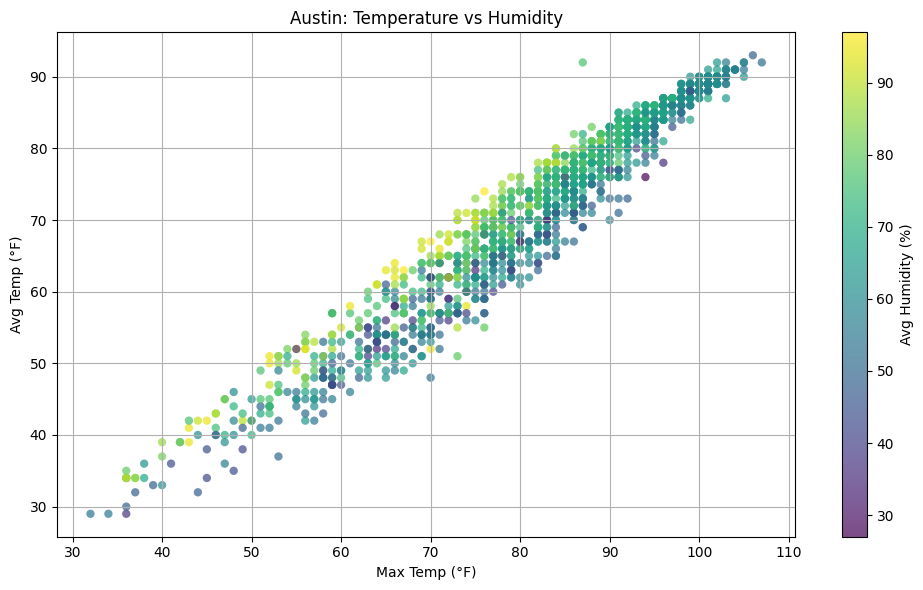

In [11]:
scatter_color(
    df_austin,
    x="TempHighF",
    y="TempAvgF",
    c="HumidityAvgPercent",
    title="Austin: Temperature vs Humidity",
    xlabel="Max Temp (°F)",
    ylabel="Avg Temp (°F)",
    clabel="Avg Humidity (%)",
    save="austin_temp_humidity.png"
)

### 4.2 Correlation Matrix

The correlation matrix quantifies linear relationships between temperature, humidity, and dew point metrics, highlighting the strength and direction of associations.

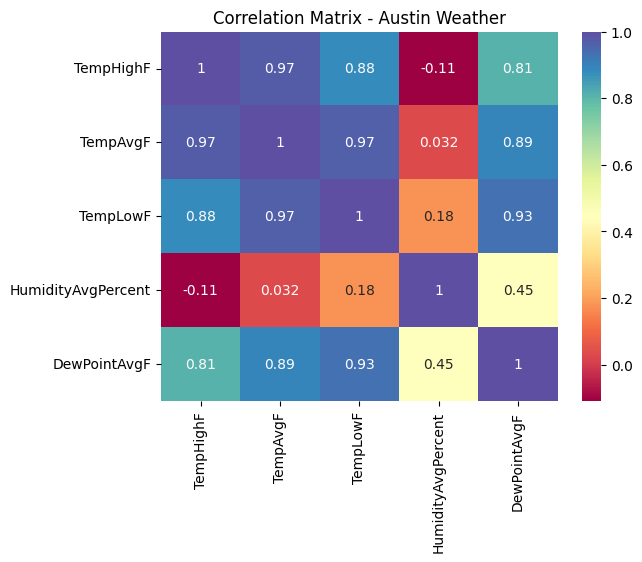

In [12]:
corr = df_austin[["TempHighF","TempAvgF","TempLowF","HumidityAvgPercent","DewPointAvgF"]].corr()
sns.heatmap(corr, annot=True, cmap="Spectral")
plt.title("Correlation Matrix - Austin Weather")
plt.show()


## 5️⃣ Temperature Time Series Overview

Time-series visualization allows observation of daily temperature fluctuations and aggregated monthly trends.  

Resampling to monthly averages reduces short-term noise and reveals broader seasonal patterns.

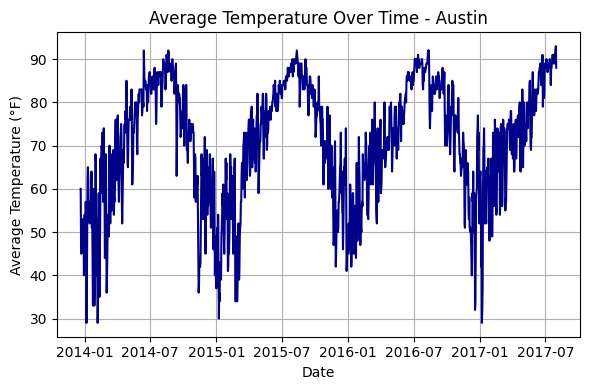

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(df_austin["Date"], df_austin["TempAvgF"], color="darkblue")
plt.title("Average Temperature Over Time - Austin")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°F)")
plt.grid(True)
plt.tight_layout()
plt.show()


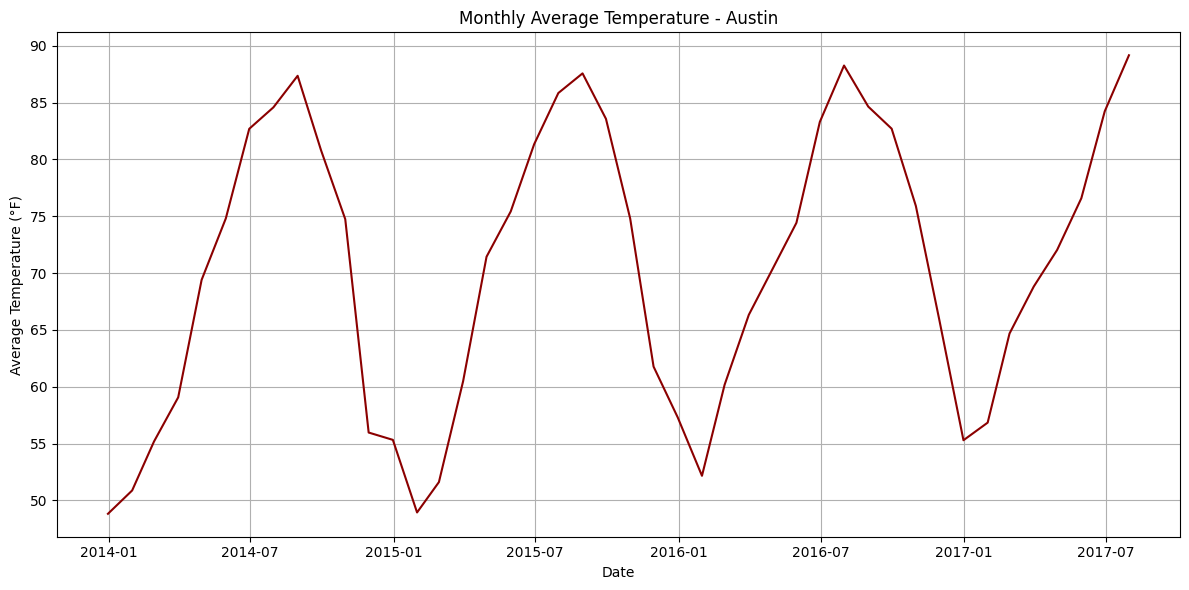

In [14]:
df_monthly = (
    df_austin
    .set_index("Date")
    .resample("ME")["TempAvgF"]
    .mean()
)

plt.figure(figsize=(12,6))
plt.plot(df_monthly.index, df_monthly.values, color="darkred")
plt.title("Monthly Average Temperature - Austin")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°F)")
plt.grid(True)
plt.tight_layout()
plt.show()

## 6️⃣ Rolling & Expanding Trend Analysis

To better understand long-term behavior, rolling and expanding averages are applied.  

Rolling means smooth short-term volatility, while the expanding mean reflects the cumulative temperature trend over time.

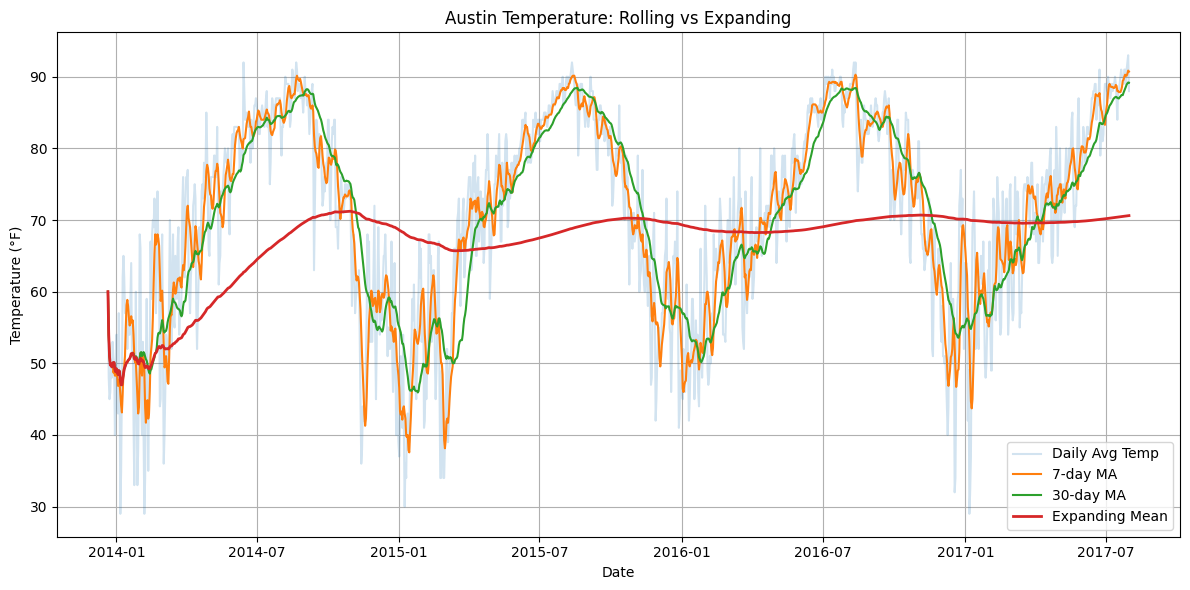

In [15]:
df_ts = df_austin.sort_values("Date").set_index("Date")

df_ts["MA_7"] = df_ts["TempAvgF"].rolling(7, min_periods=1).mean()
df_ts["MA_30"] = df_ts["TempAvgF"].rolling(30, min_periods=1).mean()
df_ts["EXP"] = df_ts["TempAvgF"].expanding().mean()

plt.figure(figsize=(12,6))
plt.plot(df_ts.index, df_ts["TempAvgF"], alpha=0.2, label="Daily Avg Temp")
plt.plot(df_ts.index, df_ts["MA_7"], label="7-day MA")
plt.plot(df_ts.index, df_ts["MA_30"], label="30-day MA")
plt.plot(df_ts.index, df_ts["EXP"], linewidth=2, label="Expanding Mean")
plt.title("Austin Temperature: Rolling vs Expanding")
plt.xlabel("Date")
plt.ylabel("Temperature (°F)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The time-series analysis reveals clear seasonality patterns, with higher temperatures during summer months and lower temperatures during winter periods. The variability appears stable across years without extreme long-term upward or downward trends.

## 7️⃣ Extreme Temperature Events

The most extreme high and low temperature days are identified to highlight unusual weather events and assess variability within the dataset.

In [16]:
top_5_hottest = df_ts.nlargest(5, "TempHighF")[["TempHighF"]]
top_5_coldest = df_ts.nsmallest(5, "TempHighF")[["TempHighF"]]

print(top_5_hottest)
print(top_5_coldest)

            TempHighF
Date                 
2017-07-29        107
2017-07-30        106
2015-08-10        105
2015-08-12        105
2016-08-12        105
            TempHighF
Date                 
2014-02-06         32
2017-01-06         34
2014-01-06         36
2014-02-11         36
2015-01-08         36


## 8️⃣ Monthly Seasonality Analysis

The monthly aggregation confirms a strong cyclical pattern, with gradual temperature increases from winter to mid-summer followed by steady declines toward late autumn.  

The stability of this pattern across the dataset suggests consistent annual climate behavior.

In [17]:
monthly_seasonality = (
    df_ts
    .groupby(df_ts.index.month)["TempAvgF"]
    .mean()
)

monthly_seasonality.index = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
    ]


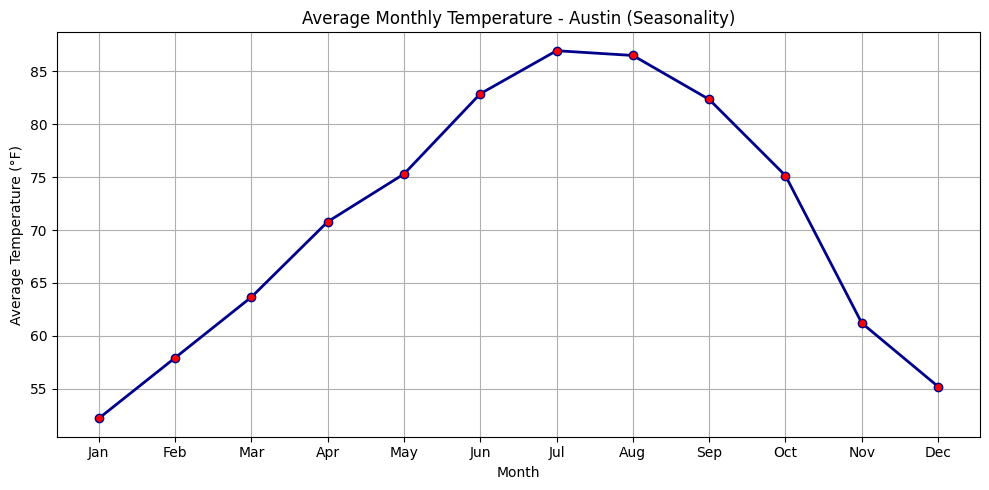

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_seasonality.index,
         monthly_seasonality.values,
         marker="o",linestyle="-",
         color="darkblue",
         markerfacecolor="red",
         linewidth=2)

plt.title("Average Monthly Temperature - Austin (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°F)")
plt.grid(True)
plt.tight_layout()
plt.show()


The seasonality analysis confirms strong cyclical temperature patterns.
Average temperatures gradually increase from January to July, peak during mid-summer, and decline toward winter months.
This clear annual cycle indicates stable climatic behavior without structural long-term shifts.

## 9️⃣ Year-over-Year Trend Validation

Yearly aggregation is performed to assess long-term temperature behavior.  

After excluding incomplete years, the long-term yearly trend reveals a mild upward movement in average temperature.  

While the increase is gradual, it aligns with broader observations of incremental warming trends over time.

In [19]:
df_ts["Year"] = df_ts.index.year
df_ts["Month"] = df_ts.index.month


In [20]:
season_matrix = (
    df_ts
    .groupby(["Year", "Month"])["TempAvgF"]
    .mean()
    .unstack()
)

In [21]:
season_matrix.columns = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

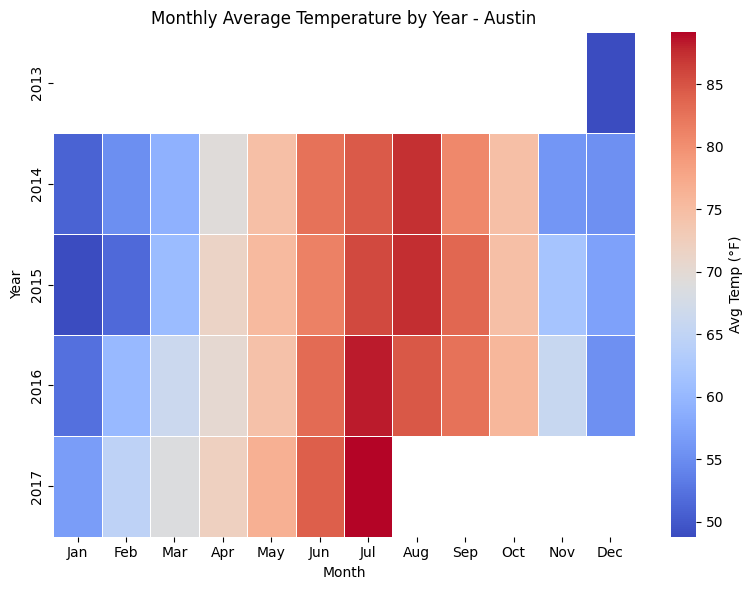

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    season_matrix,
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "Avg Temp (°F)"}
)

plt.title("Monthly Average Temperature by Year - Austin")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

The seasonality heatmap highlights consistent annual temperature cycles across years.
Summer months (June–August) consistently show the highest average temperatures, while winter months remain significantly cooler.
No abrupt structural climate shifts are observed, indicating stable long-term seasonal patterns.

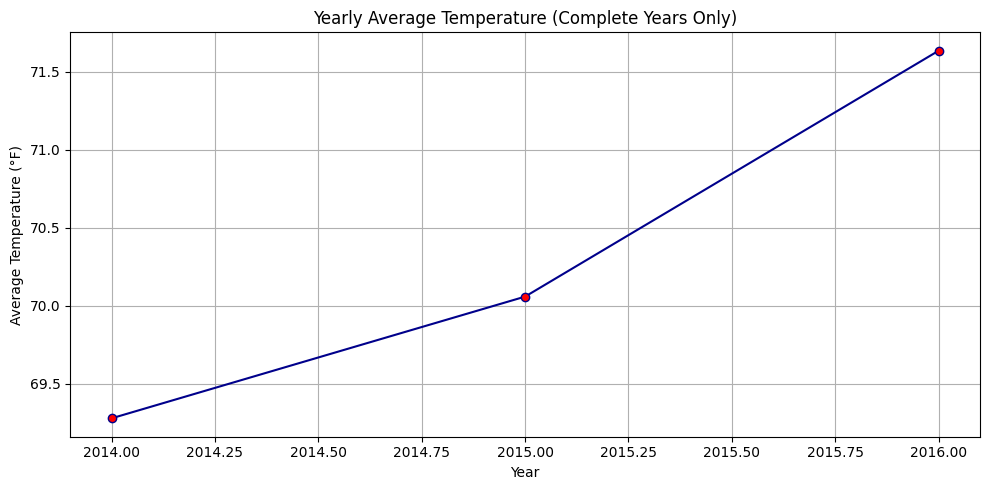

In [23]:
yearly_count = df_ts["TempAvgF"].resample("YE").count()
yearly_mean = df_ts["TempAvgF"].resample("YE").mean()

yearly_check = pd.DataFrame({
    "MeanTemp": yearly_mean,
    "DaysCount": yearly_count
})

full_years = yearly_check[yearly_check["DaysCount"] > 300]

plt.figure(figsize=(10,5))
plt.plot(
    full_years.index.year,
    full_years["MeanTemp"],
    marker="o",
    linestyle="-",
    color="darkblue",
    markerfacecolor="red"
)

plt.title("Yearly Average Temperature (Complete Years Only)")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°F)")
plt.grid(True)
plt.tight_layout()
plt.show()

Only years with more than 300 recorded days were included in the yearly trend analysis to avoid distortion caused by incomplete data coverage.
The filtered results indicate a slight upward temperature trend over the observed period.

### 9.1 Quantitative Summary

In [24]:
mean_annual_temp = full_years["MeanTemp"].mean()
highest_mean_temp = full_years["MeanTemp"].max()
lowest_mean_temp = full_years["MeanTemp"].min()

print(f"Mean annual temperature: {mean_annual_temp:.2f} °F")
print(f"Highest yearly mean temperature: {highest_mean_temp:.2f} °F")
print(f"Lowest yearly mean temperature: {lowest_mean_temp :.2f} °F")


Mean annual temperature: 70.32 °F
Highest yearly mean temperature: 71.63 °F
Lowest yearly mean temperature: 69.28 °F


## 🔟 Final Conclusion

The exploratory analysis confirms strong seasonal temperature cycles in Austin, with predictable summer peaks and winter lows.  

Rolling and expanding averages demonstrate stable climatic behavior with no abrupt structural changes.  

After filtering incomplete years, the yearly analysis suggests a mild upward temperature tendency across the observed period.  

Overall, the dataset reflects consistent seasonality with gradual long-term variation.